In [ ]:
!git clone --single-branch -b master https://github.com/HuuTuan180404/master-deep-learning.git

In [1]:
!nvidia-smi

Tue Aug  4 17:12:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.84                 Driver Version: 595.84         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:81:00.0 Off |                  N/A |
|  0%   31C    P8             23W /  350W |       1MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Setup Libs & Env

In [6]:
pip install torchattacks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 90.3 kB/s  0:06:49m0:00:0200:11m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [torchattacks] [torchattacks]
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 19.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 50.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 20.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [timm]2m 9/10 [timm]ngface_hub]
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install einops

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 68.5 kB/s  0:02:17m0:00:0400:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [15]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

import time
import random
import shutil

import torchvision
import torchvision.utils
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.amp import autocast, GradScaler

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary
from sklearn.model_selection import train_test_split

In [16]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [17]:
pwd

'/data/home/admin/master-deep-learning'

In [18]:
cd Locality-iN-Locality

/data/home/admin/master-deep-learning/Locality-iN-Locality


In [19]:
checkpoint_dir = '../checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Data & Dataloader

### Download the dataset

In [20]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  12.0M      0  0:00:21  0:00:21 --:--:-- 13.8M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  9320k      0  0:00:09  0:00:09 --:--:-- 14.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  51572      0  0:00:01  0:00:01 --:--:-- 51563


In [21]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [22]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')


test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)


with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()


# image_names[0]: is header
for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]

  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

### Create train data

In [23]:
torch.backends.cudnn.benchmark = True

batch_size = 64
num_epochs = 50

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

trainset = torchvision.datasets.ImageFolder(
    root="./data/GTSRB/Final_Training/Images",
    transform=train_transform
)

testset = torchvision.datasets.ImageFolder(
    root="./data/GTSRB/test",
    transform=test_transform
)

targets = np.array(trainset.targets)
class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = torch.from_numpy(weight[targets]).double()
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# Visualization

In [24]:
batch = next(iter(train_loader))
train_data = batch[0]

In [25]:
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image


def plot_images(images, labels, classes, normalize=True):
    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

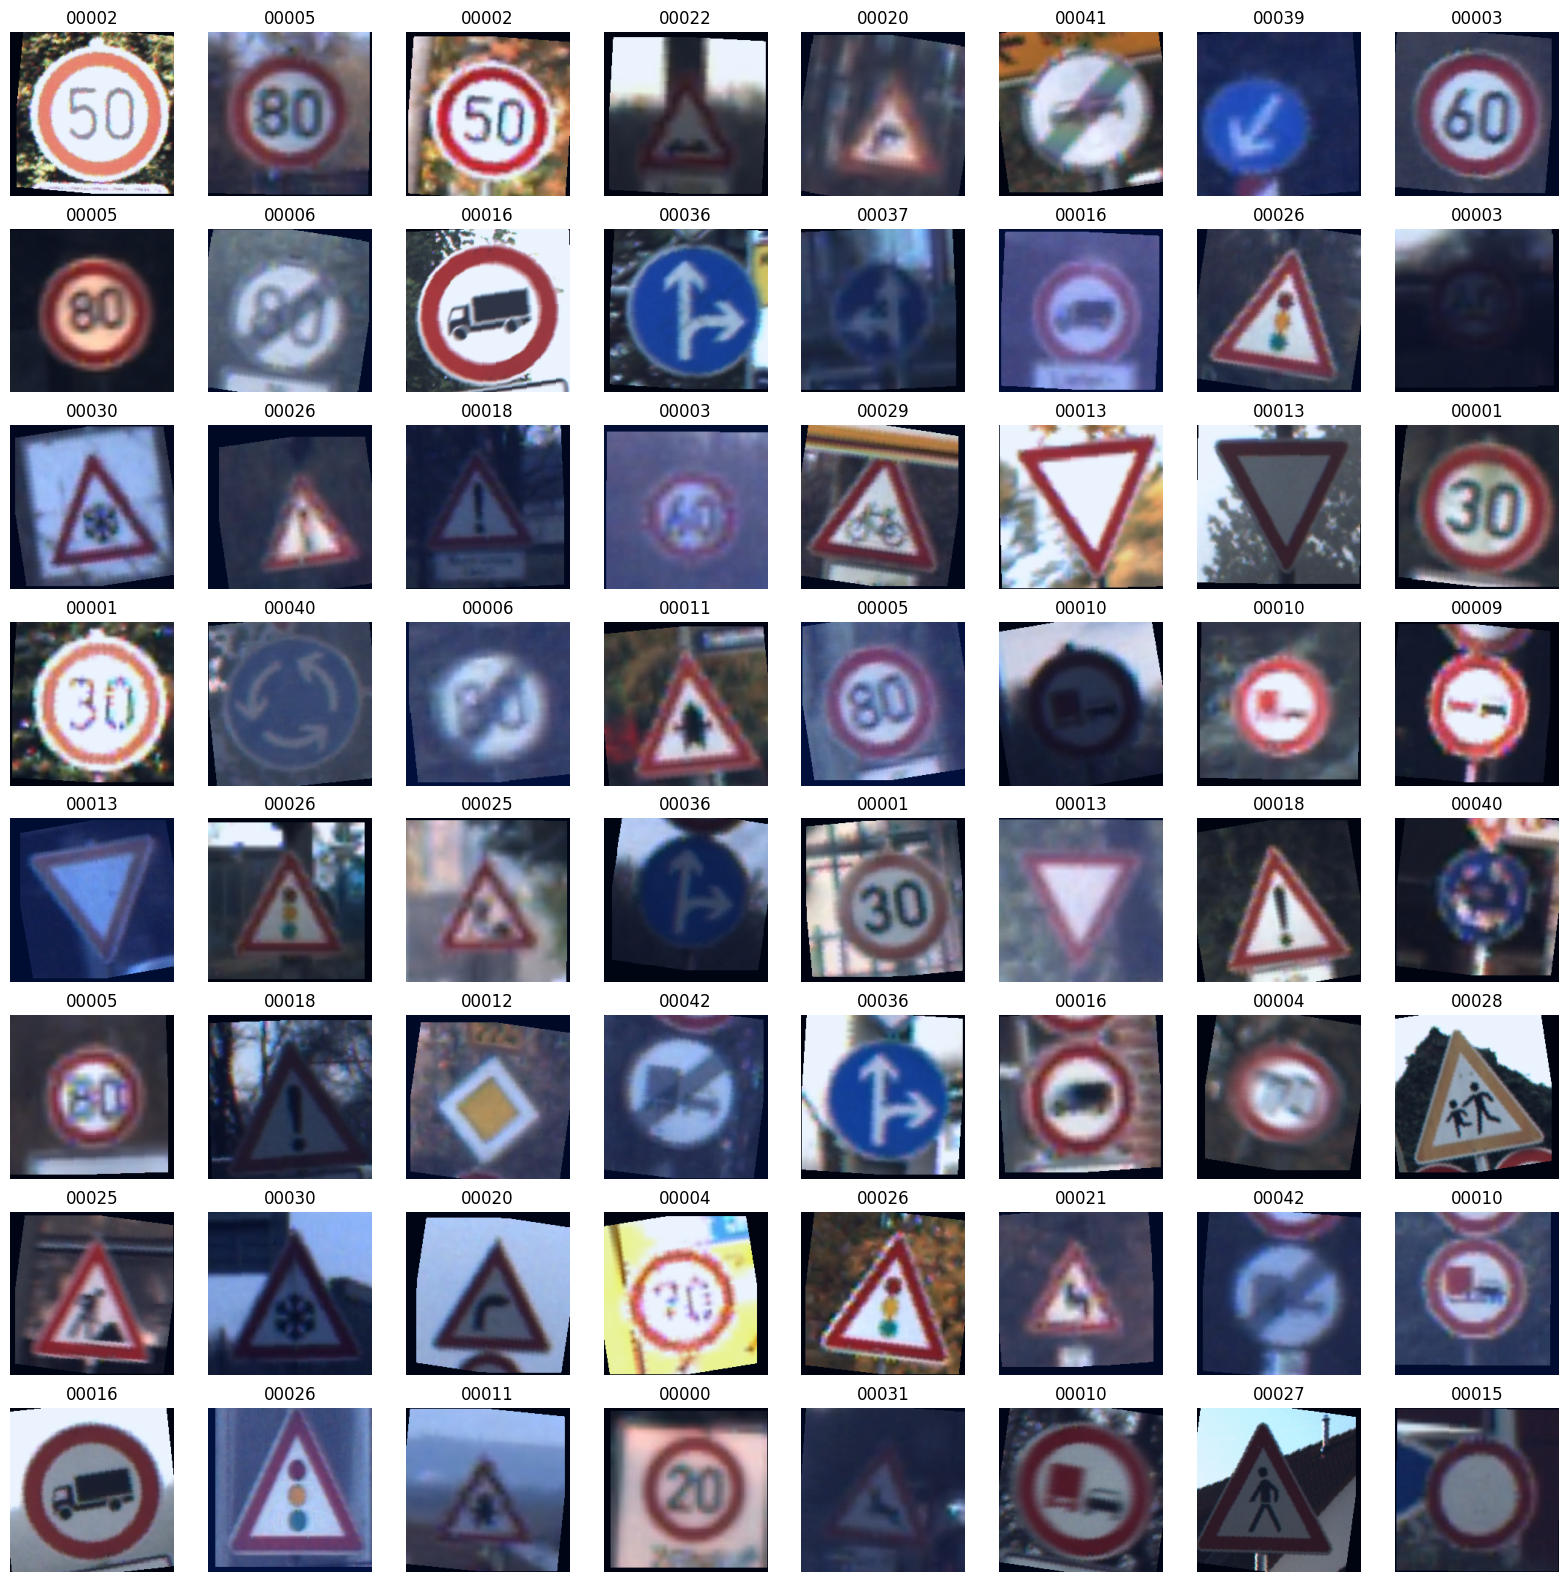

In [26]:
classes = trainset.classes
plot_images(batch[0], batch[1], classes)

# LNL Model

In [27]:
from LNL import LNL_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)
model = model.cuda()

/home/admin/.conda/envs/gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/admin/.conda/envs/gpu/lib/python3.10/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/admin/.conda/envs/gpu/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/admin/.conda/envs/gpu/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please impor

# Loss - Optimizer - Scheduler

In [28]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)


# Train

In [29]:
scaler = GradScaler("cuda")

best_loss = float("inf")
best_checkpoint_path = os.path.join(checkpoint_dir, f"best_model.pth")

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.cuda(non_blocking=True)
        labels = labels.cuda(non_blocking=True)

        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


        if (i + 1) % 200 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Iter [{i+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )

    scheduler.step()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    lr = scheduler.get_last_lr()[0]

    print("-" * 60)
    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"LR: {lr:.7f}"
    )

    if train_loss < best_loss:
        best_loss = train_loss
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }, best_checkpoint_path)
        print("Best model saved.")

Epoch [1/50] Iter [200/613] Loss: 1.9596
Epoch [1/50] Iter [400/613] Loss: 0.7806
Epoch [1/50] Iter [600/613] Loss: 0.7280
------------------------------------------------------------
Epoch 01/50 | Loss: 1.5185 | Train Acc: 74.79% | LR: 0.0000999
Best model saved.
Epoch [2/50] Iter [200/613] Loss: 0.7132
Epoch [2/50] Iter [400/613] Loss: 0.7047
Epoch [2/50] Iter [600/613] Loss: 0.7136
------------------------------------------------------------
Epoch 02/50 | Loss: 0.7183 | Train Acc: 99.80% | LR: 0.0000996
Best model saved.
Epoch [3/50] Iter [200/613] Loss: 0.6968
Epoch [3/50] Iter [400/613] Loss: 0.7079
Epoch [3/50] Iter [600/613] Loss: 0.6953
------------------------------------------------------------
Epoch 03/50 | Loss: 0.7032 | Train Acc: 99.88% | LR: 0.0000991
Best model saved.
Epoch [4/50] Iter [200/613] Loss: 0.6917
Epoch [4/50] Iter [400/613] Loss: 0.6920
Epoch [4/50] Iter [600/613] Loss: 0.6925
------------------------------------------------------------
Epoch 04/50 | Loss: 0

# Test

### Test the model above

In [30]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        outputs = model(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 99.38 %


### Test best checkpoint

In [31]:
from LNL import LNL_Ti as small

model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)
model = model.cuda()

checkpoint = torch.load(best_checkpoint_path)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.cuda()
model.eval()

correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        outputs = model(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 99.38 %
